# Model Development

## Objective

The objective of this notebook is to train, compare, and evaluate multiple regression models for predicting oral temperature using infrared thermography measurements.

The workflow includes:

- Loading engineered data
- Training baseline models
- Comparing model performance
- Evaluating predictions
- Selecting the best-performing model

In [81]:
# Libraries
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the Preprocessor
preprocessor = joblib.load("../models/preprocessor.pkl")

In [3]:
# Load dataset
df = pd.read_csv("../data/cleaned.csv")

In [4]:
# Split Features and Target
TARGET = "aveOralF"

X = df.drop(columns=["aveOralF"])

y = df[TARGET]

In [5]:
# Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [6]:
# Transform the Data
X_train = preprocessor.transform(X_train)

X_test = preprocessor.transform(X_test)

In [7]:
# Build the Models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

In [8]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    r2 = r2_score(y_test, predictions)

    results.append(
        {
            "Model": name,
            "MAE": mae,
            "RMSE": rmse,
            "R² Score": r2
        }
    )

## Model Comparison Summary

Six regression models were evaluated using MAE, RMSE, and R² Score.

Gradient Boosting achieved the best overall performance with:

- MAE: 0.166°C
- RMSE: 0.218°C
- R² Score: 0.606

This indicates that the model predicts oral temperature with an average error of approximately 0.17°C while explaining about 61% of the variability in the target variable.

Random Forest ranked second, while Linear and Ridge Regression achieved comparable performance, suggesting the presence of both linear and non-linear relationships within the data.

Decision Tree and Lasso Regression produced substantially weaker results, with Lasso Regression failing to outperform a simple baseline prediction.

In [9]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="R² Score",
    ascending=False
)

,Model,MAE,RMSE,R² Score
5,Gradient Boosting,0.165691,0.217785,0.605891
4,Random Forest,0.172404,0.230464,0.558665
1,Ridge Regression,0.188008,0.237594,0.530936
0,Linear Regression,0.189442,0.239264,0.524320
3,Decision Tree,0.235049,0.301569,0.244329
2,Lasso Regression,0.233728,0.347131,-0.001260


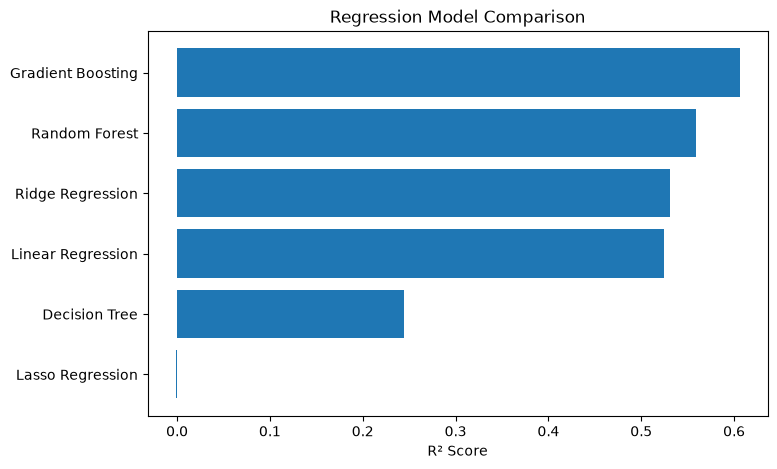

In [10]:
# Visualize Model Performance
results_df = results_df.sort_values(
    by="R² Score",
    ascending=True
)

plt.figure(figsize=(8,5))

plt.barh(
    results_df["Model"],
    results_df["R² Score"]
)

plt.xlabel("R² Score")
plt.title("Regression Model Comparison")

plt.show()

In [11]:
# Select the best model
best_model_name = results_df.iloc[-1]["Model"]

print(best_model_name)

Gradient Boosting


In [12]:
# Retrain the Best Model
best_model = RandomForestRegressor(
    random_state=42
)

best_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [23]:
# Prediction
predictions = best_model.predict(X_test)

In [24]:
# Evaluation Metrics
print("MAE :", mean_absolute_error(y_test, predictions))

print("RMSE :", np.sqrt(mean_squared_error(y_test, predictions)))

print("R² :", r2_score(y_test, predictions))

MAE : 0.17240441176470533
RMSE : 0.23046441018679023
R² : 0.5586649554773646


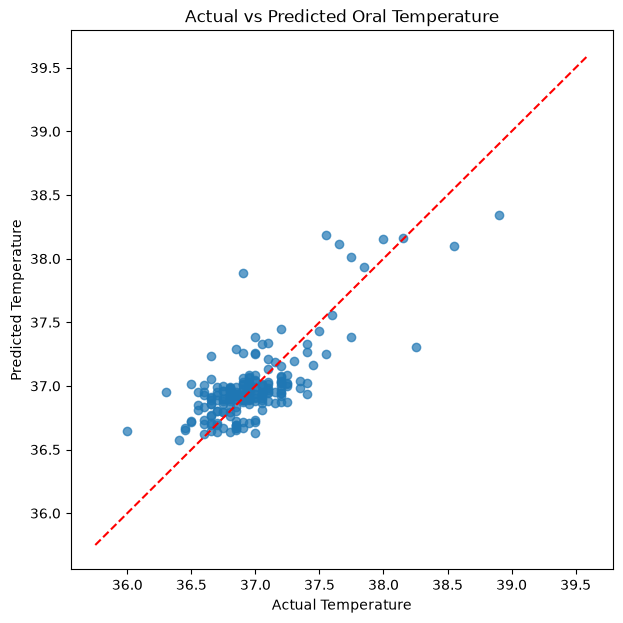

In [25]:
# Actual vs Predicted Plot
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    predictions,
    alpha=0.7
)

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    "r--"
)

plt.xlabel("Actual Temperature")

plt.ylabel("Predicted Temperature")

plt.title("Actual vs Predicted Oral Temperature")

plt.show()


In [26]:
# Feature Importance (Tree-Based Models)
feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
27,num__T_Max1,0.241717
29,num__T_OR_Max1,0.230538
28,num__T_OR1,0.218738
25,num__T_FH_Max1,0.030493
10,num__T_RC_Wet1,0.022614
0,num__T_atm,0.017292
1,num__Humidity,0.015712
3,num__T_offset1,0.014196
16,num__RCC1,0.014062
6,num__aveAllR13_1,0.013886


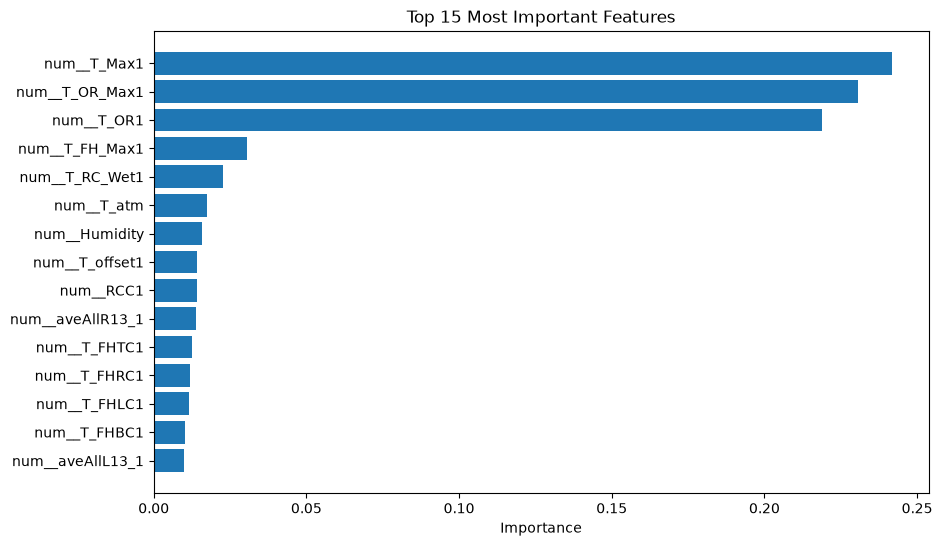

In [27]:
# Visualization
top_features = importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Most Important Features")

plt.xlabel("Importance")

plt.show()

In [28]:
# Save the Best Model
joblib.dump(
    best_model,
    "../models/best_model.pkl"
)

['../models/best_model.pkl']

## Hyperparameter Tuning

To improve model performance, hyperparameter tuning was performed on the two best-performing algorithms identified during baseline evaluation:

- Random Forest Regressor
- Gradient Boosting Regressor

GridSearchCV with 5-fold cross-validation was used to evaluate multiple combinations of hyperparameters. The optimized models were then evaluated on the held-out test set using MAE, RMSE, and R² Score. The best-performing tuned model was selected for deployment.

In [29]:
# Create the parameter grid
rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [30]:
# Create GridSearchCV
rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42
    ),
    param_grid=rf_params,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

In [31]:
# Run the tuning
rf_grid.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto

In [32]:
print("Best Random Forest Parameters:")

print(rf_grid.best_params_)

Best Random Forest Parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}


In [33]:
print(
    "Best Cross-Validation R²:",
    rf_grid.best_score_
)

Best Cross-Validation R²: 0.5899930821263835


In [34]:
# Get the best model
best_rf = rf_grid.best_estimator_

In [35]:
rf_tuned_predictions = best_rf.predict(X_test)

In [36]:
rf_default = RandomForestRegressor(
    random_state=42
)

rf_default.fit(X_train, y_train)

rf_default_predictions = rf_default.predict(X_test)

rf_default_mae = mean_absolute_error(
    y_test,
    rf_default_predictions
)

rf_default_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_default_predictions
    )
)

rf_default_r2 = r2_score(
    y_test,
    rf_default_predictions
)

print("Random Forest (Default)")
print("----------------------")
print(f"MAE : {rf_default_mae:.6f}")
print(f"RMSE: {rf_default_rmse:.6f}")
print(f"R²  : {rf_default_r2:.6f}")


Random Forest (Default)
----------------------
MAE : 0.172404
RMSE: 0.230464
R²  : 0.558665


In [37]:
# Get the best model
rf_tuned_mae = mean_absolute_error(
    y_test,
    rf_tuned_predictions
)

rf_tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_tuned_predictions
    )
)

rf_tuned_r2 = r2_score(
    y_test,
    rf_tuned_predictions
)

In [38]:
print("Random Forest — Tuned")
print("---------------------")
print("MAE :", rf_tuned_mae)
print("RMSE:", rf_tuned_rmse)
print("R²  :", rf_tuned_r2)

Random Forest — Tuned
---------------------
MAE : 0.17385291042994966
RMSE: 0.23397033551708896
R²  : 0.5451352593396672


In [39]:
# Establish the default model
gb_default = GradientBoostingRegressor(
    random_state=42
)

gb_default.fit(
    X_train,
    y_train
)

gb_default_predictions = gb_default.predict(
    X_test
)

In [40]:
# Calculate metrics
gb_default_mae = mean_absolute_error(
    y_test,
    gb_default_predictions
)

gb_default_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_default_predictions
    )
)

gb_default_r2 = r2_score(
    y_test,
    gb_default_predictions
)


In [41]:
print("Gradient Boosting — Default")
print("---------------------------")
print("MAE :", gb_default_mae)
print("RMSE:", gb_default_rmse)
print("R²  :", gb_default_r2)

Gradient Boosting — Default
---------------------------
MAE : 0.16569052727914496
RMSE: 0.217785025796983
R²  : 0.6058906765327476


In [42]:
# Create Gradient Boosting Parameter Grid# 
gb_params = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "subsample": [0.8, 1.0]
}

In [43]:
# Create GridSearchCV
gb_grid = GridSearchCV(
    estimator=GradientBoostingRegressor(
        random_state=42
    ),
    param_grid=gb_params,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

In [44]:
# Run the Gradient Boosting tuning
gb_grid.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...], 'subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_

In [45]:
# See the Best Parameters
print("Best Gradient Boosting Parameters:")
print(gb_grid.best_params_)

Best Gradient Boosting Parameters:
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}


In [46]:
print(
    "Best Cross-Validation R²:",
    gb_grid.best_score_
)

Best Cross-Validation R²: 0.5924069261480783


In [47]:
# Get the best model
best_gb = gb_grid.best_estimator_

In [48]:
gb_tuned_predictions = best_gb.predict(
    X_test
)

In [49]:
gb_default = GradientBoostingRegressor(random_state=42)

gb_default.fit(X_train, y_train)

gb_default_predictions = gb_default.predict(X_test)

gb_default_mae = mean_absolute_error(
    y_test,
    gb_default_predictions
)

gb_default_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_default_predictions
    )
)

gb_default_r2 = r2_score(
    y_test,
    gb_default_predictions
)

In [50]:
# Calculate metrics
gb_tuned_mae = mean_absolute_error(
    y_test,
    gb_tuned_predictions
)

gb_tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_tuned_predictions
    )
)

gb_tuned_r2 = r2_score(
    y_test,
    gb_tuned_predictions
)

In [51]:
print("Gradient Boosting — Tuned")
print("-------------------------")
print("MAE :", gb_tuned_mae)
print("RMSE:", gb_tuned_rmse)
print("R²  :", gb_tuned_r2)

Gradient Boosting — Tuned
-------------------------
MAE : 0.16917885588934853
RMSE: 0.22529465962890594
R²  : 0.5782428320614112


In [52]:
# Comparism
comparison = pd.DataFrame({
    "Model": [
        "Random Forest (Default)",
        "Random Forest (Tuned)",
        "Gradient Boosting (Default)",
        "Gradient Boosting (Tuned)"
    ],

    "MAE": [
        rf_default_mae,
        rf_tuned_mae,
        gb_default_mae,
        gb_tuned_mae
    ],

    "RMSE": [
        rf_default_rmse,
        rf_tuned_rmse,
        gb_default_rmse,
        gb_tuned_rmse
    ],

    "R²": [
        rf_default_r2,
        rf_tuned_r2,
        gb_default_r2,
        gb_tuned_r2
    ]
})

comparison.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)


,Model,MAE,RMSE,R²
0,Gradient Boosting (Default),0.165691,0.217785,0.605891
1,Gradient Boosting (Tuned),0.169179,0.225295,0.578243
2,Random Forest (Default),0.172404,0.230464,0.558665
3,Random Forest (Tuned),0.173853,0.233970,0.545135


In [53]:
if gb_tuned_r2 >= rf_tuned_r2:
    final_model = best_gb
    final_model_name = "Gradient Boosting"
else:
    final_model = best_rf
    final_model_name = "Random Forest"

print("Final Model:", final_model_name)

Final Model: Gradient Boosting


In [54]:
# Save model
import joblib

joblib.dump(best_model, "../models/best_model.pkl")

print("Best model saved successfully.")

Best model saved successfully.


## Model Development Summary

- Trained six regression models.
- Evaluated each using MAE, RMSE, and R² Score.
- Compared model performance.
- Selected the best-performing model.
- Visualized predicted vs actual temperatures.
- Examined feature importance for model interpretability.
- Saved the trained model for deployment.

## Hyperparameter Tuning Results

Hyperparameter tuning was performed on the two best-performing algorithms identified during baseline evaluation:

- Random Forest Regressor
- Gradient Boosting Regressor

GridSearchCV with 5-fold cross-validation was used to systematically evaluate different combinations of model hyperparameters.

The tuned models were evaluated on the held-out test set using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The tuned model with the strongest overall test performance was selected as the final model for deployment.

Baseline evaluation identified Gradient Boosting and Random Forest as the two strongest algorithms. Hyperparameter tuning was subsequently performed using 5-fold cross-validation. However, the tuned configurations did not outperform the corresponding baseline models on the held-out test set. The default Gradient Boosting Regressor achieved the best overall performance, with an MAE of 0.166, RMSE of 0.218°C, and R² of 0.606, and was therefore selected as the final model.

## Feature Importance Analysis

Feature importance was analyzed to understand which variables contributed most to the Gradient Boosting model's prediction of oral temperature.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

final_model = GradientBoostingRegressor(
    random_state=42
)

final_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [56]:
print(len(final_model.feature_importances_))

46


In [57]:
feature_names = preprocessor.get_feature_names_out()

print(len(feature_names))
print(feature_names)

46
['num__T_atm' 'num__Humidity' 'num__Distance' 'num__T_offset1'
 'num__Max1R13_1' 'num__Max1L13_1' 'num__aveAllR13_1' 'num__aveAllL13_1'
 'num__T_RC1' 'num__T_RC_Dry1' 'num__T_RC_Wet1' 'num__T_RC_Max1'
 'num__T_LC1' 'num__T_LC_Dry1' 'num__T_LC_Wet1' 'num__T_LC_Max1'
 'num__RCC1' 'num__LCC1' 'num__canthiMax1' 'num__canthi4Max1'
 'num__T_FHCC1' 'num__T_FHRC1' 'num__T_FHLC1' 'num__T_FHBC1'
 'num__T_FHTC1' 'num__T_FH_Max1' 'num__T_FHC_Max1' 'num__T_Max1'
 'num__T_OR1' 'num__T_OR_Max1' 'cat__Gender_Female' 'cat__Gender_Male'
 'cat__Age_18-20' 'cat__Age_21-25' 'cat__Age_21-30' 'cat__Age_26-30'
 'cat__Age_31-40' 'cat__Age_41-50' 'cat__Age_51-60' 'cat__Age_>60'
 'cat__Ethnicity_American Indian or Alaskan Native' 'cat__Ethnicity_Asian'
 'cat__Ethnicity_Black or African-American'
 'cat__Ethnicity_Hispanic/Latino' 'cat__Ethnicity_Multiracial'
 'cat__Ethnicity_White']


In [58]:
feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
29,num__T_OR_Max1,0.347453
27,num__T_Max1,0.280426
28,num__T_OR1,0.127245
25,num__T_FH_Max1,0.030814
10,num__T_RC_Wet1,0.023139
9,num__T_RC_Dry1,0.022981
21,num__T_FHRC1,0.015879
3,num__T_offset1,0.014802
0,num__T_atm,0.011968
16,num__RCC1,0.011333


In [59]:
top_15_features = feature_importance.head(15)

top_15_features

,Feature,Importance
29,num__T_OR_Max1,0.347453
27,num__T_Max1,0.280426
28,num__T_OR1,0.127245
25,num__T_FH_Max1,0.030814
10,num__T_RC_Wet1,0.023139
9,num__T_RC_Dry1,0.022981
21,num__T_FHRC1,0.015879
3,num__T_offset1,0.014802
0,num__T_atm,0.011968
16,num__RCC1,0.011333


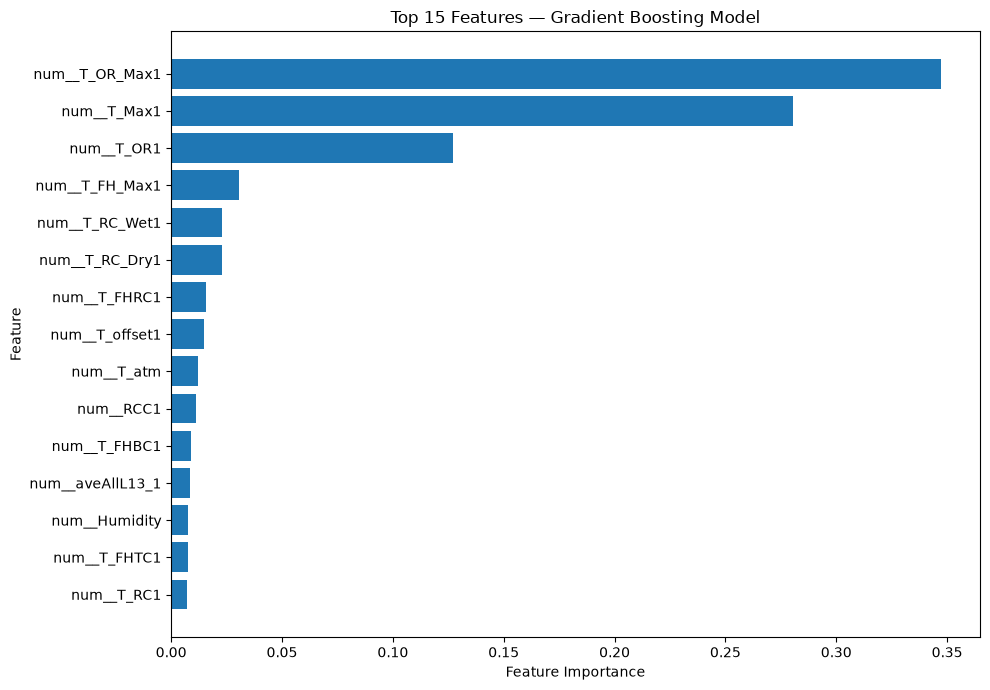

In [60]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_15_features["Feature"][::-1],
    top_15_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features — Gradient Boosting Model")

plt.tight_layout()
plt.show()

In [61]:
top_15_features_display = top_15_features.copy()

top_15_features_display["Feature"] = (
    top_15_features_display["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

top_15_features_display

,Feature,Importance
29,T_OR_Max1,0.347453
27,T_Max1,0.280426
28,T_OR1,0.127245
25,T_FH_Max1,0.030814
10,T_RC_Wet1,0.023139
9,T_RC_Dry1,0.022981
21,T_FHRC1,0.015879
3,T_offset1,0.014802
0,T_atm,0.011968
16,RCC1,0.011333


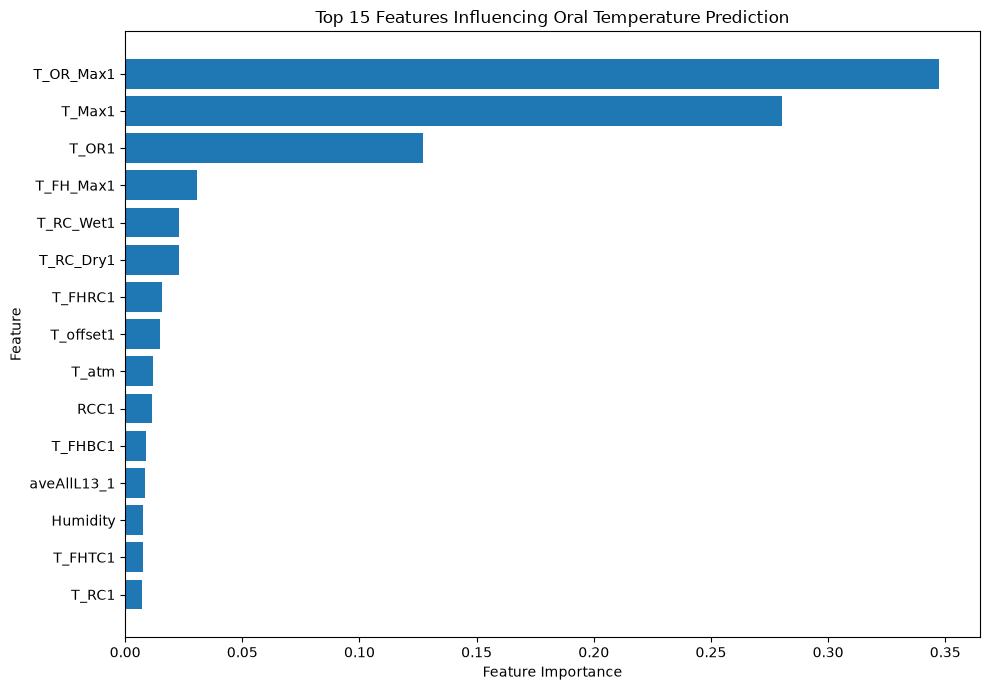

In [62]:
# Cleaner chart
plt.figure(figsize=(10, 7))

plt.barh(
    top_15_features_display["Feature"][::-1],
    top_15_features_display["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Influencing Oral Temperature Prediction")

plt.tight_layout()
plt.show()

In [ ]:
# Calculate permutation importance
perm_importance = permutation_importance(
    final_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2",
    n_jobs=-1
)

In [ ]:
# Create the permutation-importance table
permutation_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance_Mean": perm_importance.importances_mean,
    "Importance_Std": perm_importance.importances_std
})

permutation_df = permutation_df.sort_values(
    by="Importance_Mean",
    ascending=False
).reset_index(drop=True)

permutation_df

,Feature,Importance_Mean,Importance_Std
0,num__T_Max1,0.213487,0.033472
1,num__T_OR_Max1,0.200830,0.026050
2,num__T_RC_Dry1,0.036639,0.009909
3,num__T_FH_Max1,0.029098,0.002954
4,num__T_atm,0.028119,0.005599
5,num__T_offset1,0.019244,0.009327
6,num__T_FHRC1,0.017275,0.006583
7,num__Max1R13_1,0.014907,0.005424
8,num__aveAllL13_1,0.013872,0.003045
9,num__T_RC1,0.012833,0.004301


In [65]:
top_15_permutation = permutation_df.head(15)

top_15_permutation

,Feature,Importance_Mean,Importance_Std
0,num__T_Max1,0.213487,0.033472
1,num__T_OR_Max1,0.200830,0.026050
2,num__T_RC_Dry1,0.036639,0.009909
3,num__T_FH_Max1,0.029098,0.002954
4,num__T_atm,0.028119,0.005599
5,num__T_offset1,0.019244,0.009327
6,num__T_FHRC1,0.017275,0.006583
7,num__Max1R13_1,0.014907,0.005424
8,num__aveAllL13_1,0.013872,0.003045
9,num__T_RC1,0.012833,0.004301


In [66]:
top_15_permutation = permutation_df.head(15).copy()

top_15_permutation["Feature"] = (
    top_15_permutation["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

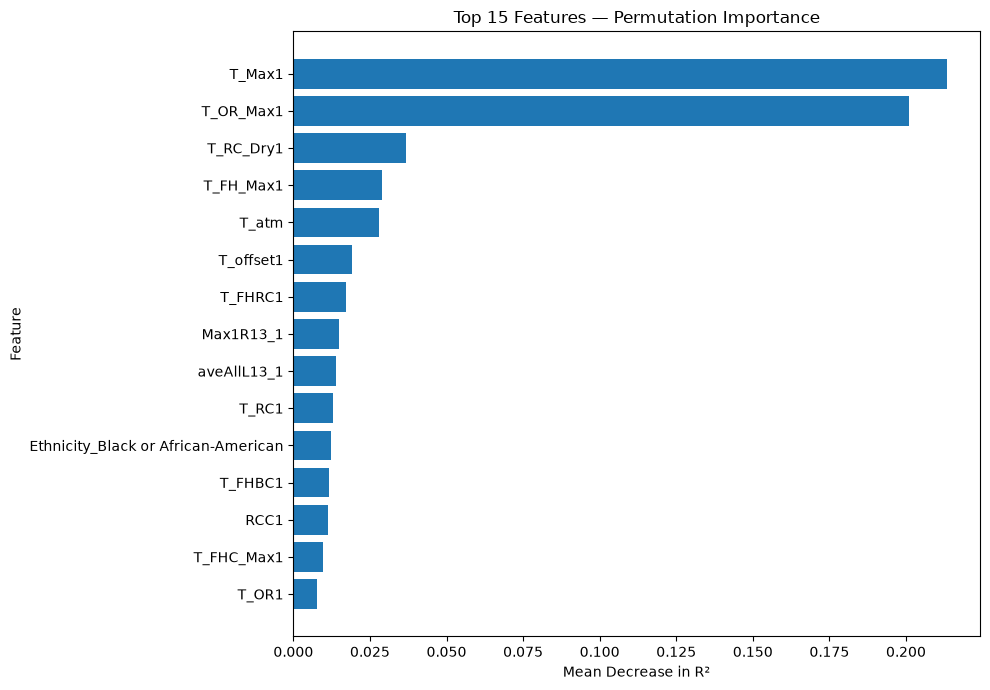

In [67]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_15_permutation["Feature"][::-1],
    top_15_permutation["Importance_Mean"][::-1]
)

plt.xlabel("Mean Decrease in R²")
plt.ylabel("Feature")
plt.title("Top 15 Features — Permutation Importance")

plt.tight_layout()
plt.show()

In [71]:
# Define the final model
final_model = GradientBoostingRegressor(
    random_state=42
)

final_model.fit(X_train, y_train)
# Generate predictions
final_predictions = final_model.predict(X_test)

print("Predictions generated successfully.")
print("Number of predictions:", len(final_predictions))

Predictions generated successfully.
Number of predictions: 204


In [72]:
# Compare actual vs predicted values
comparison_df = pd.DataFrame({
    "Actual Temperature": y_test,
    "Predicted Temperature": final_predictions
})

comparison_df.head(10)

,Actual Temperature,Predicted Temperature
523,36.90,36.993803
602,36.75,36.736606
526,36.75,36.641429
31,36.65,36.882041
616,36.80,36.868090
585,36.75,36.963965
444,37.50,37.411711
732,37.20,36.959923
76,37.00,36.922410
411,37.20,36.879199


In [73]:
# Calculate the prediction error
comparison_df["Error"] = (
    comparison_df["Actual Temperature"]
    - comparison_df["Predicted Temperature"]
)

comparison_df.head(10)

,Actual Temperature,Predicted Temperature,Error
523,36.90,36.993803,-0.093803
602,36.75,36.736606,0.013394
526,36.75,36.641429,0.108571
31,36.65,36.882041,-0.232041
616,36.80,36.868090,-0.068090
585,36.75,36.963965,-0.213965
444,37.50,37.411711,0.088289
732,37.20,36.959923,0.240077
76,37.00,36.922410,0.077590
411,37.20,36.879199,0.320801


In [74]:
# Calculate absolute error
comparison_df["Absolute Error"] = comparison_df["Error"].abs()

comparison_df.head(10)

,Actual Temperature,Predicted Temperature,Error,Absolute Error
523,36.90,36.993803,-0.093803,0.093803
602,36.75,36.736606,0.013394,0.013394
526,36.75,36.641429,0.108571,0.108571
31,36.65,36.882041,-0.232041,0.232041
616,36.80,36.868090,-0.068090,0.068090
585,36.75,36.963965,-0.213965,0.213965
444,37.50,37.411711,0.088289,0.088289
732,37.20,36.959923,0.240077,0.240077
76,37.00,36.922410,0.077590,0.077590
411,37.20,36.879199,0.320801,0.320801


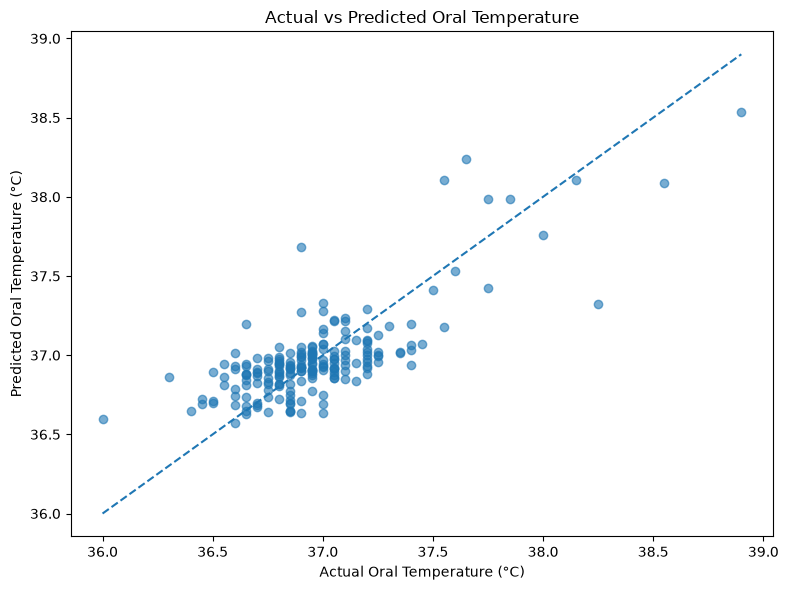

In [75]:
# Create the Actual vs Predicted plot

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.6
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Oral Temperature (°C)")
plt.ylabel("Predicted Oral Temperature (°C)")
plt.title("Actual vs Predicted Oral Temperature")

plt.tight_layout()
plt.show()

In [76]:
# residual analysis
comparison_df["Residual"] = (
    comparison_df["Actual Temperature"]
    - comparison_df["Predicted Temperature"]
)

In [77]:
comparison_df["Residual"].describe()

count    204.000000
mean      -0.011710
std        0.218005
min       -0.782188
25%       -0.143984
50%       -0.021083
75%        0.122730
max        0.928764
Name: Residual, dtype: float64

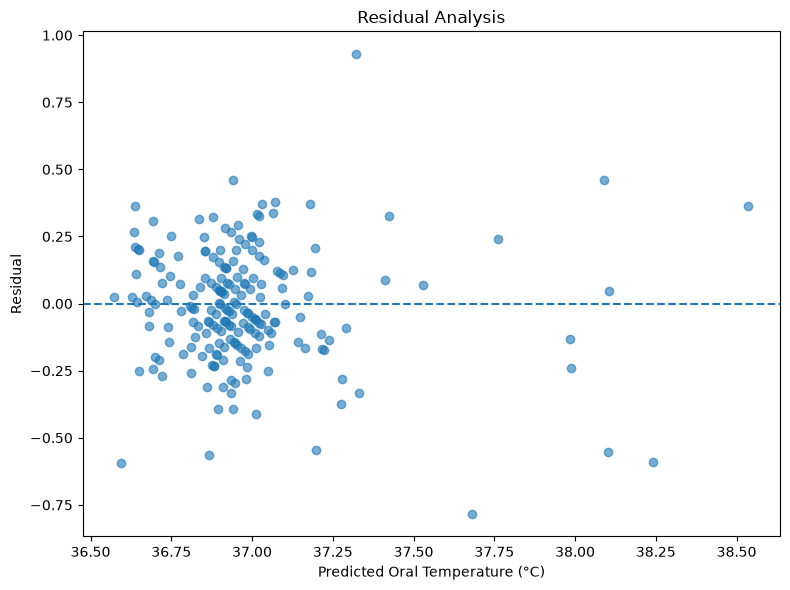

In [78]:
plt.figure(figsize=(8, 6))

plt.scatter(
    final_predictions,
    comparison_df["Residual"],
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Oral Temperature (°C)")
plt.ylabel("Residual")
plt.title("Residual Analysis")

plt.tight_layout()
plt.show()


In [79]:
# Check the worst predictions
worst_predictions = comparison_df.sort_values(
    by="Absolute Error",
    ascending=False
)

worst_predictions.head(10)

,Actual Temperature,Predicted Temperature,Error,Absolute Error,Residual
803,38.25,37.321236,0.928764,0.928764,0.928764
314,36.90,37.682188,-0.782188,0.782188,-0.782188
477,36.00,36.595019,-0.595019,0.595019,-0.595019
72,37.65,38.241755,-0.591755,0.591755,-0.591755
329,36.30,36.865271,-0.565271,0.565271,-0.565271
136,37.55,38.103430,-0.553430,0.553430,-0.553430
514,36.65,37.196522,-0.546522,0.546522,-0.546522
998,38.55,38.089467,0.460533,0.460533,0.460533
30,37.40,36.940138,0.459862,0.459862,0.459862
530,36.60,37.011013,-0.411013,0.411013,-0.411013


In [80]:
# Calculate the percentage of predictions within an error threshold
within_02 = (
    comparison_df["Absolute Error"] <= 0.2
).mean() * 100

print(f"Predictions within ±0.2°C: {within_02:.2f}%")

within_03 = (
    comparison_df["Absolute Error"] <= 0.3
).mean() * 100

print(f"Predictions within ±0.3°C: {within_03:.2f}%")

within_05 = (
    comparison_df["Absolute Error"] <= 0.5
).mean() * 100

print(f"Predictions within ±0.5°C: {within_05:.2f}%")

Predictions within ±0.2°C: 69.61%
Predictions within ±0.3°C: 85.78%
Predictions within ±0.5°C: 96.57%


The Actual vs Predicted analysis indicates that the Gradient Boosting model performs well within the dominant normal-temperature range but shows reduced accuracy at extreme temperature values. Predictions tend to regress toward the central temperature range, resulting in underprediction of higher temperatures and occasional overprediction of lower temperatures.

And for the residual analysis:

Residuals are generally distributed around zero, indicating limited systematic bias across the majority of observations. However, several larger residuals are present at extreme temperature values, suggesting that the model has difficulty capturing less frequent observations.

In [82]:
# Cross-validate Gradient Boosting
gb_cv_scores = cross_val_score(
    GradientBoostingRegressor(
    random_state=42
),
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

gb_cv_scores

array([0.65881268, 0.3116658 , 0.60310128, 0.7109425 , 0.42368104])

In [83]:
# Calculate the mean CV score
gb_cv_mean = gb_cv_scores.mean()

print(f"Mean Cross-Validation R²: {gb_cv_mean:.4f}")

Mean Cross-Validation R²: 0.5416


In [84]:
# Standard deviation
gb_cv_std = gb_cv_scores.std()

print(f"Cross-Validation R² Std: {gb_cv_std:.4f}")

Cross-Validation R² Std: 0.1503


Mean R² = 0.54

Across the five validation folds, the model explains approximately 58% of the variance in oral temperature.

Standard deviation = 0.15

The model's performance doesn't fluctuate dramatically between folds.

That's a good sign.

In [97]:
# cross-validate MAE
gb_mae_scores = cross_val_score(
    GradientBoostingRegressor(
        random_state=42
    ),
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

In [98]:
gb_mae_scores = -gb_mae_scores

print("MAE scores:", gb_mae_scores)
print(f"Mean Cross-Validation MAE: {gb_mae_scores.mean():.4f}")
print(f"MAE Std: {gb_mae_scores.std():.4f}")

MAE scores: [0.18155253 0.17515418 0.16678504 0.17537807 0.19021001]
Mean Cross-Validation MAE: 0.1778
MAE Std: 0.0078


In [99]:
# Cross-validate RMSE
gb_rmse_scores = cross_val_score(
    GradientBoostingRegressor(
            random_state=42
        ),
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

gb_rmse_scores = -gb_rmse_scores

print("RMSE scores:", gb_rmse_scores)
print(f"Mean Cross-Validation RMSE: {gb_rmse_scores.mean():.4f}")
print(f"RMSE Std: {gb_rmse_scores.std():.4f}")

RMSE scores: [0.26491792 0.24070783 0.23994597 0.25267805 0.26021009]
Mean Cross-Validation RMSE: 0.2517
RMSE Std: 0.0101


In [100]:
# Put everything into one summary
gb_cv_summary = pd.DataFrame({
    "Metric": [
        "R²",
        "MAE",
        "RMSE"
    ],
    "Mean": [
        gb_cv_scores.mean(),
        gb_mae_scores.mean(),
        gb_rmse_scores.mean()
    ],
    "Std": [
        gb_cv_scores.std(),
        gb_mae_scores.std(),
        gb_rmse_scores.std()
    ]
})

gb_cv_summary

,Metric,Mean,Std
0,R²,0.541641,0.150315
1,MAE,0.177816,0.007775
2,RMSE,0.251692,0.010071


In [103]:
final_validation_summary = pd.DataFrame({
    "Evaluation": [
        "Test Set",
        "5-Fold Cross-Validation"
    ],
    "MAE": [
        0.165691,
        gb_mae_scores.mean()
    ],
    "RMSE": [
        0.217785,
        gb_rmse_scores.mean()
    ],
    "R²": [
        0.605891,
        gb_cv_scores.mean()
    ]
})

final_validation_summary.round(4)


,Evaluation,MAE,RMSE,R²
0,Test Set,0.1657,0.2178,0.6059
1,5-Fold Cross-Validation,0.1778,0.2517,0.5416


In [102]:
# evaluate the Random Forest
rf_cv_scores = cross_val_score(
    RandomForestRegressor(
    random_state=42
),
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Random Forest CV R² scores:")
print(rf_cv_scores)

print(f"\nMean R²: {rf_cv_scores.mean():.4f}")
print(f"Std R²: {rf_cv_scores.std():.4f}")

Random Forest CV R² scores:
[0.6782121  0.39060424 0.60749805 0.72519976 0.4930105 ]

Mean R²: 0.5789
Std R²: 0.1224
